#  Healthcare Data Analysis using Python

##  Objective
The objective of this project is to analyze healthcare data to understand patterns in patient Diagnosis, treatment costs, and disease distribution. This analysis helps in identifying cost trends and the impact of insurance coverage.

## Dataset Description

The dataset contains the following columns:

- Patient_ID: Unique identifier for each patient  
- Age: Age of the patient  
- Gender: Male/Female  
- City: Patient location  
- Diagnosis: Type of disease  
- Hospital_Visits: Number of visits  
- Treatment_Cost: Cost of treatment  
- Insurance_Coverage: Whether insurance is available  
- Admission_Date: Date of hospital admission

## Data Cleaning

- Converted Admission_Date from text to datetime format  
- Handled missing values in Age using median imputation  
- Filled missing Treatment_Cost using diagnosis-wise average  
- Checked and removed data inconsistencies  

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/healthcare_data_cleaning_dataset.csv")
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [10]:
df.info()
df.isnull().sum()

# Convert date
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# Fill missing values (recommended method)
df['Age'] = df.groupby('Diagnosis')['Age'].transform(
    lambda x: x.fillna(x.median()))

df['Treatment_Cost'] = df.groupby('Diagnosis')['Treatment_Cost'].transform(
    lambda x: x.fillna(x.mean())
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Patient_ID          5100 non-null   int64         
 1   Age                 5100 non-null   float64       
 2   Gender              5100 non-null   object        
 3   City                5100 non-null   object        
 4   Diagnosis           5100 non-null   object        
 5   Hospital_Visits     5100 non-null   int64         
 6   Treatment_Cost      5100 non-null   float64       
 7   Insurance_Coverage  5100 non-null   int64         
 8   Admission_Date      5100 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 358.7+ KB


In [12]:
df['Age'].isnull().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Patient_ID          5100 non-null   int64         
 1   Age                 5100 non-null   float64       
 2   Gender              5100 non-null   object        
 3   City                5100 non-null   object        
 4   Diagnosis           5100 non-null   object        
 5   Hospital_Visits     5100 non-null   int64         
 6   Treatment_Cost      5100 non-null   float64       
 7   Insurance_Coverage  5100 non-null   int64         
 8   Admission_Date      5100 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 358.7+ KB


In [13]:
""" Analysis Questions
Q1) Average Treatment Cost
"""

df['Treatment_Cost'].mean()

np.float64(26919.315790907225)

In [14]:
"""
Q2) Patients by Gender
"""
df['Gender'].value_counts()


,count
Gender,
Male,2585
Female,2515


In [15]:
"""
Q3) Most Common Disease
"""
df['Diagnosis'].value_counts().head()

,count
Diagnosis,
Hypertension,1062
Diabetes,1048
COVID-19,1022
Flu,993
Asthma,975


In [16]:
"""
Q4) City-wise Patients
"""
df['City'].value_counts()


,count
City,
Mumbai,1086
Hyderabad,1025
Bangalore,1016
Chennai,1010
Delhi,963


In [17]:
"""
Q5) Age vs Cost
"""
df.groupby('Age')['Treatment_Cost'].mean()


,Treatment_Cost
Age,
0.0,28321.264599
1.0,30001.554914
2.0,24764.357143
3.0,27103.769231
4.0,27568.392857
...,...
95.0,30437.693481
96.0,25809.869565
97.0,24424.722222


In [18]:
"""
Q6) Insurance Impact
"""
df.groupby('Insurance_Coverage')['Treatment_Cost'].mean()

,Treatment_Cost
Insurance_Coverage,
0,27301.317096
1,26521.410508


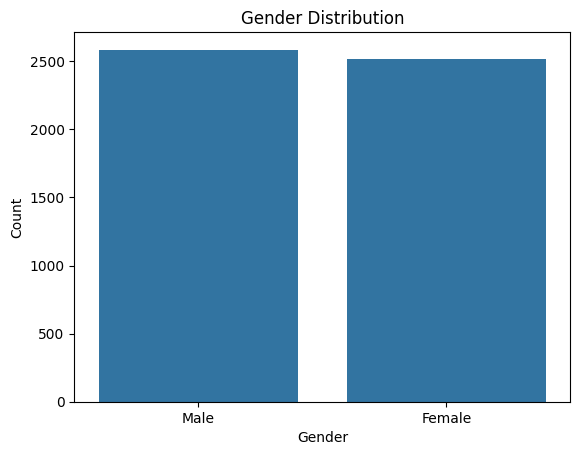

In [26]:
""" Visualization
Q7) Gender Distribution
"""
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


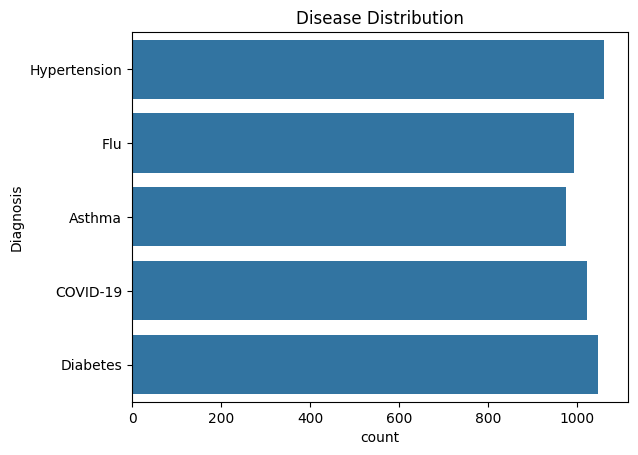

In [27]:
"""
Q8) Diagnosis Distribution
"""

sns.countplot(y='Diagnosis', data=df)
plt.title("Disease Distribution")
plt.show()

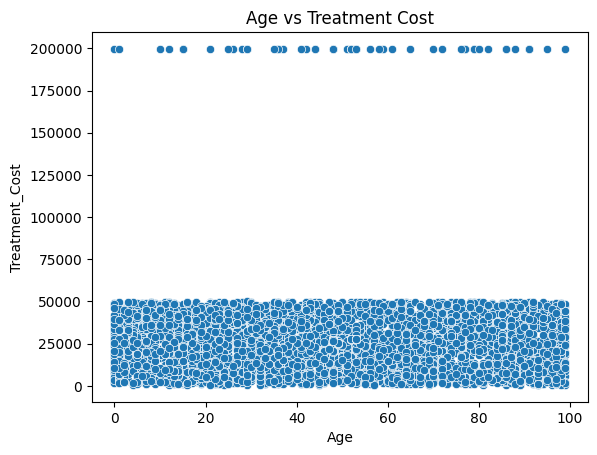

In [29]:
"""
Q9) Cost by Age
"""
sns.scatterplot(x='Age', y='Treatment_Cost', data=df)
plt.title("Age vs Treatment Cost")
plt.show()

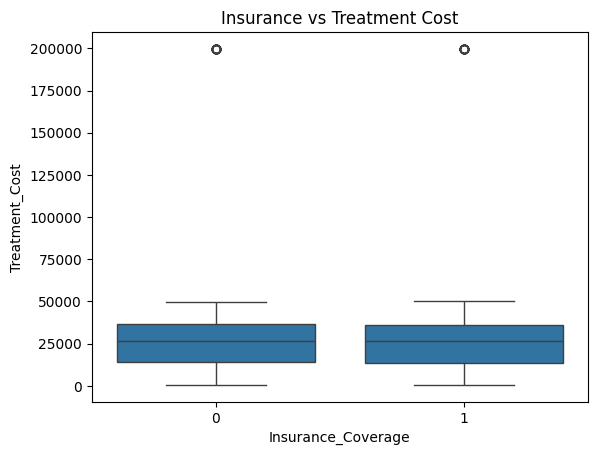

In [28]:
"""
Q10) Insurance vs Cost
"""
sns.boxplot(x='Insurance_Coverage', y='Treatment_Cost', data=df)
plt.title("Insurance vs Treatment Cost")
plt.show()

## Healthcare Data Analysis:

### Key Insights
- Most common diagnosis is Hypertension
- Patients with insurance have lower treatment cost
- Higher age groups tend to have higher medical expenses
- Mumbai has high City-wise Patients

##  Conclusion

This project demonstrates how Python can be used to clean, analyze, and visualize healthcare data to derive meaningful insights for decision-making.